# India Campaign Genome 2026 🇮🇳
## Decoding 90 Days of Publicly Reported Indian Marketing Activity

This notebook analyzes a **retrospective, public-source sample** of Indian marketing actions reported between June and August 2026. The project focuses on marketing strategy—not fabricated performance outcomes.

**Research themes:** named-talent dependency, occasion marketing, localization, standardized marketing roles, AI/data-led execution, channel concentration and creative diversity.

## 1. Research design

Each row represents an observable marketing action reported by an industry or official source. `reported_date` is the publication/reporting date, not necessarily the exact launch date. Several strategy fields are manually coded, so findings should be described as patterns in this sample rather than population-level facts about all Indian advertising.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.features import enrich
from src.metrics import rate_by_group, channel_hhi, creative_diversity

df = pd.read_csv(ROOT / 'data/raw/india_campaign_genome_90d.csv')
df = enrich(df)
df.head()

,record_id,reported_date,brand,sector,action_type,campaign_or_action,primary_objective,occasion_context,geography_focus,celebrity_or_creator,talent_used,primary_channel,creative_strategy,ai_data_angle,funnel_stage,source_publication,source_url,coding_confidence,notes,occasion_flag,regional_localization,month,week_start,sector_group,reported_month,lower_funnel_flag,talent_label,occasion_label
0,ICG-001,2026-06-01,Reliance Digital,Consumer Electronics Retail,Campaign Launch,Boot Up 2026,Build awareness around AI-ready devices and om...,NaN,India,None stated,0,Integrated / Omnichannel,Technology-led proposition; retail + digital a...,1,Awareness,Exchange4media,https://www.exchange4media.com/articles/2026-0...,High,NaN,0,0,2026-06,2026-06-01,Retail & Commerce,2026-06,0,No named talent stated,Not occasion-linked
1,ICG-002,2026-06-02,Mother's Recipe,FMCG - Food,Campaign + Packaging Refresh,National pickle identity refresh,Refresh brand identity while linking regional ...,NaN,India,None stated,0,Integrated,Regional culture + emotional family storytelling,0,Awareness,Campaign India,https://www.campaignindia.in/news/regional,High,NaN,0,0,2026-06,2026-06-02,FMCG / Food & Beverage,2026-06,0,No named talent stated,Not occasion-linked
2,ICG-003,2026-06-05,PayNearby Saathi,Fintech,Campaign Launch,Trust-led digital finance adoption campaign,Build trust in digital-finance adoption throug...,NaN,Bharat / India,None stated,0,Not stated,"Trust, retailer advocacy and behavioural insight",0,Consideration,Campaign India,https://www.campaignindia.in/news/regional,High,NaN,0,0,2026-06,2026-06-05,Financial Services,2026-06,0,No named talent stated,Not occasion-linked
3,ICG-004,2026-06-08,Mother Dairy,FMCG - Dairy,Sustainability Campaign,World Environment Day degradable-packaging com...,Turn packaging innovation into a visible susta...,World Environment Day,India,None stated,0,Packaging / Integrated,Sustainability proof through product packaging,0,Awareness,Campaign India,https://www.campaignindia.in/news/regional,High,NaN,1,0,2026-06,2026-06-08,FMCG / Food & Beverage,2026-06,0,No named talent stated,Occasion-linked
4,ICG-005,2026-06-08,Pernod Ricard India,Beverages,Media Agency Review,Media agency review,Reassess media planning and buying partnership...,NaN,India,None stated,0,Paid Media,Media operating-model review,0,Strategy,Exchange4media,https://www.exchange4media.com/articles/2026-0...,High,Reported marketing spend was cited in the sour...,0,0,2026-06,2026-06-08,FMCG / Food & Beverage,2026-06,0,No named talent stated,Not occasion-linked


## 2. Data quality and coverage

In [2]:
summary = pd.Series({
    'Observed marketing actions': len(df),
    'Unique brands / partnerships': df['brand'].nunique(),
    'Granular sectors': df['sector'].nunique(),
    'Named-talent share': df['talent_used'].mean(),
    'Occasion-linked share': df['occasion_flag'].mean(),
    'AI/data-led share': df['ai_data_angle'].mean(),
    'Regional/localized share': df['regional_localization'].mean(),
})
summary

Observed marketing actions      91.000000
Unique brands / partnerships    88.000000
Granular sectors                69.000000
Named-talent share               0.395604
Occasion-linked share            0.252747
AI/data-led share                0.164835
Regional/localized share         0.131868
dtype: float64

In [3]:
print('Missing values by field (top 10):')
display(df.isna().sum().sort_values(ascending=False).head(10))
print('Duplicate record IDs:', df['record_id'].duplicated().sum())
print('Date range:', df['reported_date'].min().date(), 'to', df['reported_date'].max().date())

Missing values by field (top 10):


notes                   87
occasion_context        68
brand                    0
record_id                0
sector                   0
action_type              0
campaign_or_action       0
primary_objective        0
geography_focus          0
celebrity_or_creator     0
dtype: int64

Duplicate record IDs: 0
Date range: 2026-06-01 to 2026-08-29


## 3. Where is observed marketing activity concentrated by standardized marketing role?

The raw `funnel_stage` field contains a mixture of funnel and strategic labels. For comparison, the repository derives a standardized `marketing_role` variable while preserving the original field.

,records
funnel_stage,
Awareness,43
Consideration,21
Conversion,10
Engagement,7
Strategy,6
Acquisition,1
Performance,1
B2B Consideration,1
Retention,1


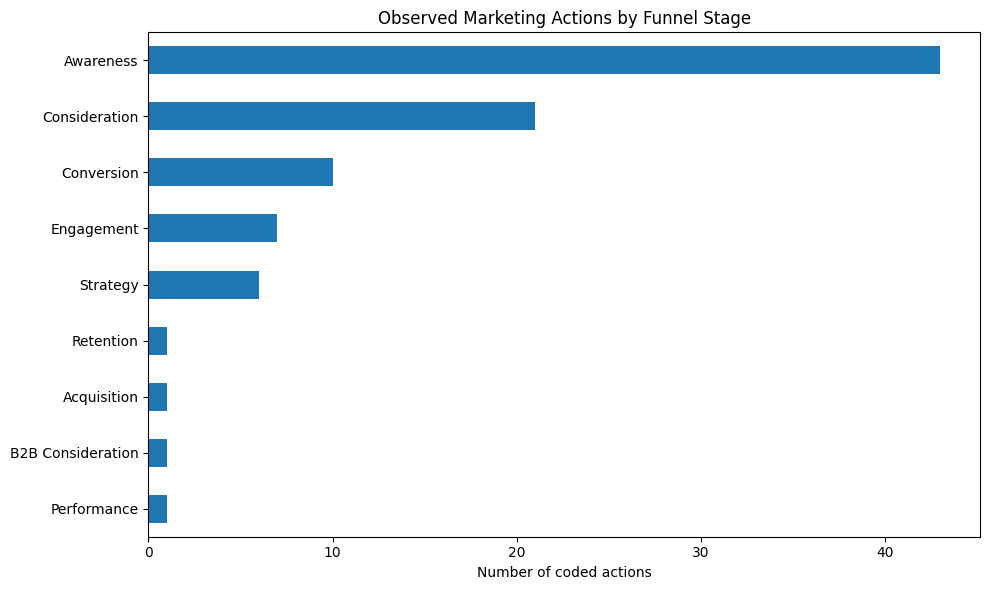

In [4]:
role_distribution = df['marketing_role'].value_counts()
display(role_distribution.to_frame('records'))

plt.figure(figsize=(10,6))
role_distribution.sort_values().plot(kind='barh')
plt.title('Observed Marketing Actions by Standardized Marketing Role')
plt.xlabel('Number of coded actions')
plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation
The distribution describes the **observed sample**, not total Indian advertising spend. A heavy awareness share can reflect both actual campaign strategy and the types of brand actions most likely to receive industry-media coverage.

## 4. Celebrity Dependency Rate

,sector_group,records,positives,rate
1,Beauty & Personal Care,8,5,0.625000
0,Automotive & Mobility,5,3,0.600000
6,"Lifestyle, Home & Fashion",18,9,0.500000
12,Travel & Hospitality,4,2,0.500000
3,FMCG / Food & Beverage,20,8,0.400000
4,Financial Services,9,3,0.333333
5,Healthcare,3,1,0.333333
7,Media & Entertainment,3,1,0.333333
11,Technology & Electronics,11,2,0.181818
9,Retail & Commerce,5,0,0.000000


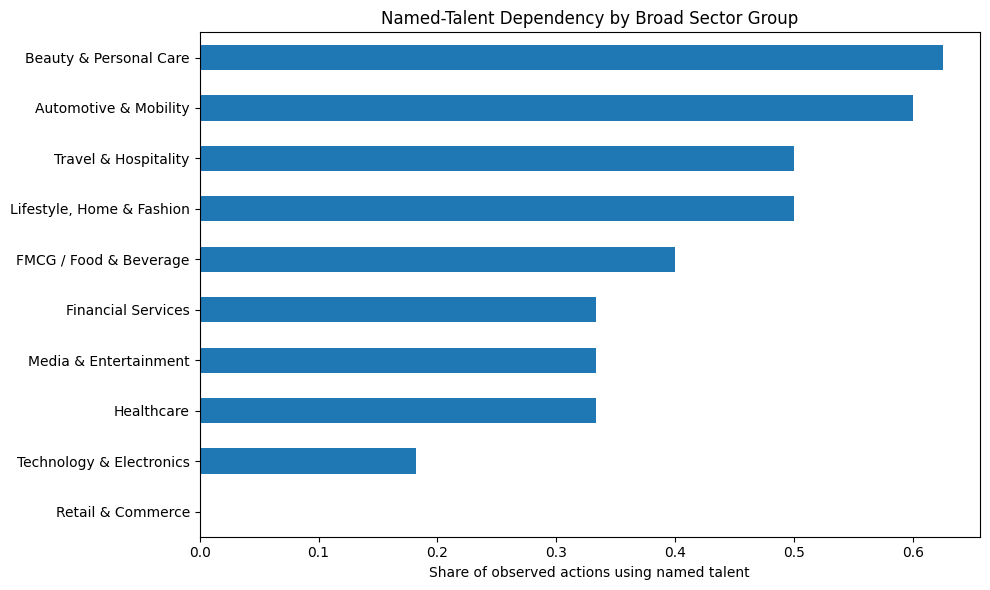

In [5]:
talent = rate_by_group(df, 'sector_group', 'talent_used', min_n=3)
display(talent)
plt.figure(figsize=(10,6))
talent.head(10).set_index('sector_group')['rate'].sort_values().plot(kind='barh')
plt.title('Named-Talent Dependency by Broad Sector Group')
plt.xlabel('Share of observed actions using named talent')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Metric:** named-talent actions ÷ observed actions in the sector group. Small denominators are filtered, but the result is still descriptive rather than causal.

## 5. Occasion marketing

In [6]:
occasion_by_month = df.groupby('reported_month')['occasion_flag'].agg(['sum','count','mean'])
display(occasion_by_month)
df.loc[df['occasion_flag'].eq(1), ['reported_date','brand','occasion_context','campaign_or_action']].sort_values('reported_date').head(25)

,sum,count,mean
reported_month,,,
2026-06,2,12,0.166667
2026-07,1,13,0.076923
2026-08,20,66,0.303030


,reported_date,brand,occasion_context,campaign_or_action
3,2026-06-08,Mother Dairy,World Environment Day,World Environment Day degradable-packaging com...
8,2026-06-18,ZEE5,FIFA / Football,15% of football subscription revenue directed ...
14,2026-07-09,Mathrubhumi,Onam,Two-version Onam campaign
25,2026-08-03,Welspun,Wimbledon,Wimbledon association amplification
31,2026-08-10,Pro Govinda League,Dahi Handi / Govinda,Suryakumar Yadav appointed brand ambassador
33,2026-08-12,Zepto,Independence Day,Independence Day campaign
34,2026-08-13,Indriya,Varalakshmi,Varalakshmi campaign for southern markets
38,2026-08-14,Nykaa,Independence season,Skin Freedom Sale 2026
39,2026-08-15,Dabur Red,Independence Day,Desh Ke Lal
40,2026-08-15,Bandhan Mutual Fund,Independence Day,Kya Azaad Ho Tum?


## 6. Regional localization

In [7]:
localized = df.loc[df['regional_localization'].eq(1), ['brand','sector_group','geography_focus','creative_strategy']]
display(localized)
print(f"Regional/localized share: {df['regional_localization'].mean():.1%}")

,brand,sector_group,geography_focus,creative_strategy
6,Spinny,Automotive & Mobility,Tamil Nadu,Localization + celebrity credibility + trust
14,Mathrubhumi,Media & Entertainment,Kerala,Regional culture + ritual storytelling
31,Pro Govinda League,"Sports, Culture & Education",Mumbai / India,Cricket celebrity crossover
34,Indriya,"Lifestyle, Home & Fashion",South India,Regional culture + celebrity
36,Cuticura,Beauty & Personal Care,Kerala,Regional celebrity + product proposition
37,Spotify,Media & Entertainment,Mumbai,Subscriber exclusivity + live culture
46,EUME,Travel & Hospitality,Mumbai Airport,Physical installation + travel context
64,Narasu's Coffee,FMCG / Food & Beverage,South India / India,Heritage + ritual storytelling
72,ENO,FMCG / Food & Beverage,India / Regional,Category education + symptom expansion
79,Hyundai Motor India + Radio Mirchi,Automotive & Mobility,7 Indian cities,Branded utility + live data


Regional/localized share: 13.2%


## 7. AI/data-led execution

In [8]:
ai_actions = df.loc[df['ai_data_angle'].eq(1), ['brand','sector_group','campaign_or_action','creative_strategy']]
display(ai_actions)
print(f"AI/data-led share: {df['ai_data_angle'].mean():.1%}")

,brand,sector_group,campaign_or_action,creative_strategy
0,Reliance Digital,Retail & Commerce,Boot Up 2026,Technology-led proposition; retail + digital a...
16,Prime Video + Amazon MX Player,Technology & Electronics,Unified advertising options,Commerce-enabled media products
18,Swiggy Instamart,Retail & Commerce,How India Instamarted,Data storytelling + earned-media design
21,Go Zero,FMCG / Food & Beverage,Influencer budget shut; in-house creator model...,Shift from rented influence to owned creator c...
22,Canon India,Technology & Electronics,Dentsu Creative Isobar wins digital and e-comm...,Integrated digital commerce management
23,ThinkResult + PubMatic,Technology & Electronics,Agentic CTV campaign via AgenticOS,AI-enabled campaign operations
27,SharkNinja,Other,WPP Media / Wavemaker appointed in India,Unified media planning and investment
28,Truecaller Ads,Technology & Electronics,Truecaller Pulse,Declared-intent audience intelligence
29,Google Gemini,Technology & Electronics,Gemini campaign with Shah Rukh Khan,Celebrity + mainstream AI storytelling
45,Exotel,Technology & Electronics,Friendship Day fragmented-CX campaign,Occasion hijack + pain-point dramatization


AI/data-led share: 16.5%


The coding aims to distinguish **AI/data as part of execution** from marketing that merely talks about AI as a theme.

## 8. Channel concentration (HHI)

In [9]:
hhi = channel_hhi(df)
display(hhi[hhi['records'] >= 3].head(12))

,sector_group,records,unique_channels,channel_hhi
5,Healthcare,3,3,0.333333
7,Media & Entertainment,3,3,0.333333
8,Other,3,3,0.333333
9,Retail & Commerce,5,4,0.280000
12,Travel & Hospitality,4,4,0.250000
6,"Lifestyle, Home & Fashion",18,9,0.240741
1,Beauty & Personal Care,8,6,0.218750
0,Automotive & Mobility,5,5,0.200000
4,Financial Services,9,7,0.185185
11,Technology & Electronics,11,10,0.107438


A higher HHI means the observed sector group's channel mix is more concentrated. With small group sizes, this is best treated as a portfolio diagnostic rather than a stable population estimate.

## 9. Creative-strategy diversity

In [10]:
diversity = creative_diversity(df)
display(diversity[diversity['records'] >= 3].head(12))

,sector_group,records,unique_strategies,creative_entropy_bits,creative_diversity_normalized
6,"Lifestyle, Home & Fashion",18,18,4.169925,1.0
11,Technology & Electronics,11,11,3.459432,1.0
3,FMCG / Food & Beverage,20,20,4.321928,1.0
1,Beauty & Personal Care,8,8,3.000000,1.0
0,Automotive & Mobility,5,5,2.321928,1.0
9,Retail & Commerce,5,5,2.321928,1.0
12,Travel & Hospitality,4,4,2.000000,1.0
4,Financial Services,9,9,3.169925,1.0
5,Healthcare,3,3,1.584963,1.0
7,Media & Entertainment,3,3,1.584963,1.0


## 10. Strategic takeaways

Use this section to convert analysis into marketing implications. Keep every conclusion tied to the sample. Good wording is: **"Within this public-source sample..."** rather than **"Indian brands always..."**.

Questions worth answering after reviewing the tables above:
- Which broad sectors show the strongest dependency on named talent?
- Does occasion-linked activity rise materially in August?
- Which sectors show actual AI/data-led activation?
- Is the sample disproportionately concentrated in awareness-stage work?
- Which sector groups use the broadest range of creative strategies?

## 11. Limitations

This is not a complete census of Indian advertising. It is a reconstructed public-source sample and can overrepresent campaigns that receive industry-media attention. Manual coding introduces judgement. No spend, ROI, sales lift, reach or engagement data have been fabricated, and this notebook does not make causal performance claims.